In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("titanic.csv");
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Making the titles of the columns uppercase 
data.columns = data.columns.str.upper()

In [6]:
data.isna().sum()

# Filled the empty age values with the median age instead
data['AGE'] = data['AGE'].fillna(data['AGE'].median())
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PASSENGERID  891 non-null    int64  
 1   SURVIVED     891 non-null    int64  
 2   PCLASS       891 non-null    int64  
 3   NAME         891 non-null    object 
 4   SEX          891 non-null    object 
 5   AGE          891 non-null    float64
 6   SIBSP        891 non-null    int64  
 7   PARCH        891 non-null    int64  
 8   TICKET       891 non-null    object 
 9   FARE         891 non-null    float64
 10  CABIN        204 non-null    object 
 11  EMBARKED     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# Deleting the Cabin column because it has a lot of NaN values
del data['CABIN']

In [10]:
data.head()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<h2> Age by passenger class class </h2>
<h4>
Passengers in 1st class tend to be older on average than those in lower classes while 3rd class shows a younger and wider spread of ages, including many children.
The spread and outliers suggest age composition differed substantially by class.
</h4>

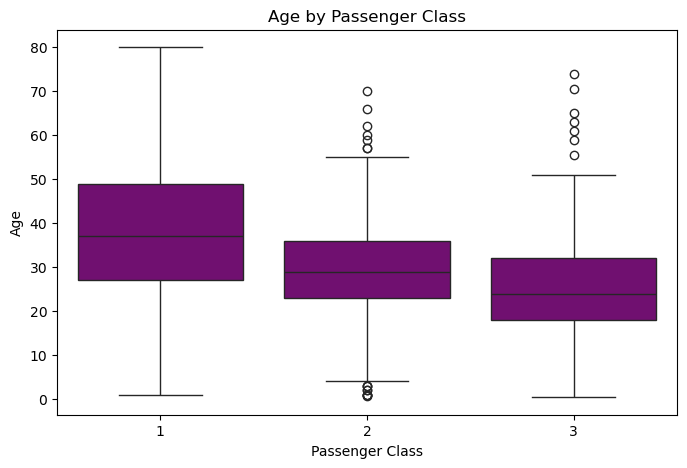

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="Pclass", y="Age", color="purple")
plt.title("Age by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

<h2>Survivors by ticket class</h2>
<h4> People in first class had a higher chance of survival as compared to other classes
</h4>

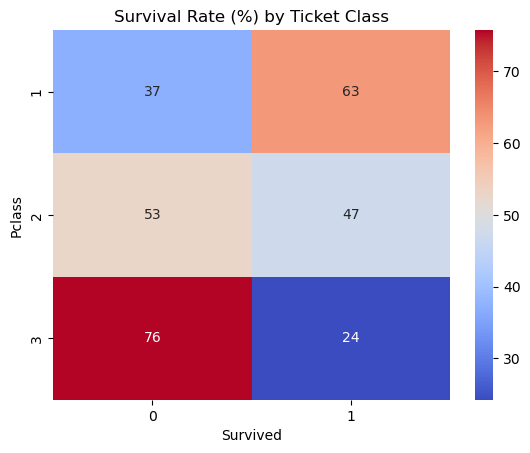

In [21]:
pclass = data.groupby(['Pclass', 'Survived']).size().unstack()
sns.heatmap(pclass.div(pclass.sum(axis=1), axis=0) * 100, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Survival Rate (%) by Ticket Class')
plt.show()


<h2> Survival by Gender </h2>
<h4> Female passengers show a much higher survival count than male passengers. More than 50% of men did not survive.
</h4>

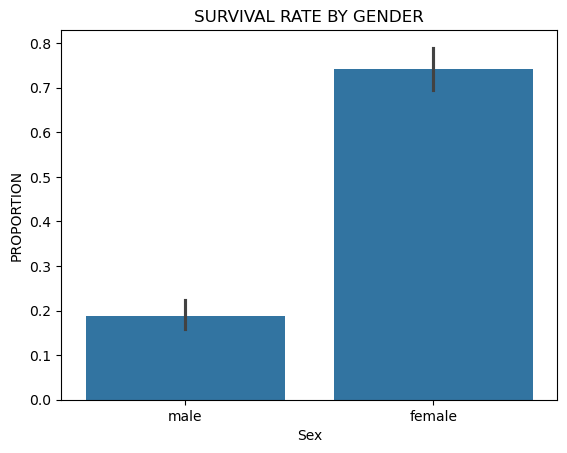

In [26]:
sns.barplot(data=data, x='Sex', y='Survived')

plt.title("SURVIVAL RATE BY GENDER")
plt.ylabel("PROPORTION")
plt.show()